In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('✅ Librairies importées avec succès')

✅ Librairies importées avec succès


In [2]:
# Chargement
df = pd.read_csv('../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv')

print(f'✅ Dataset chargé : {df.shape[0]} clients, {df.shape[1]} features')
print()
df.head()

✅ Dataset chargé : 4372 clients, 52 features



,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,...,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,...,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1


In [4]:
print('INFORMATIONS GÉNÉRALES')
print(f'Nombre de lignes    : {df.shape[0]}')
print(f'Nombre de colonnes  : {df.shape[1]}')
print(f'Mémoire utilisée    : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print()
print('Types de données :')
print(df.dtypes.value_counts())

INFORMATIONS GÉNÉRALES
Nombre de lignes    : 4372
Nombre de colonnes  : 52
Mémoire utilisée    : 5578.8 KB

Types de données :
int64      20
object     18
float64    14
Name: count, dtype: int64


In [5]:
# Séparer features numériques et catégorielles
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'Features numériques ({len(num_cols)}) :')
print(num_cols)
print()
print(f'Features catégorielles ({len(cat_cols)}) :')
print(cat_cols)

Features numériques (34) :
['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'SupportTicketsCount', 'SatisfactionScore', 'Churn']

Features catégorielles (18) :
['RegistrationDate', 'NewsletterSubscribed', 'LastLoginIP', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountStatus', 'C

In [6]:
# Statistiques descriptives des features numériques
print('Statistiques descriptives — Features numériques :')
df[num_cols].describe().round(2)

Statistiques descriptives — Features numériques :


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,ZeroPriceCount,CancelledTransactions,ReturnRatio,TotalTransactions,UniqueInvoices,AvgLinesPerInvoice,Age,SupportTicketsCount,SatisfactionScore,Churn
count,4372.00,4372.00,4372.00,4372.00,4372.00,4372.00,4372.00,4372.00,4372.00,4372.00,...,4372.00,4372.00,4372.00,4372.00,4372.00,4372.00,3061.00,4372.00,4372.00,4372.00
mean,15299.68,92.05,5.08,1898.46,28.84,88.67,-86.43,185.18,1122.34,22.39,...,0.01,2.04,0.03,93.05,5.08,19.88,49.15,21.78,5.33,0.33
std,1722.39,100.77,9.34,8219.35,127.32,2689.00,2876.40,2881.28,4672.79,213.26,...,0.13,7.34,0.11,232.47,9.34,18.51,18.27,139.27,15.41,0.47
min,12346.00,1.00,1.00,-4287.63,-4287.63,0.00,-168469.60,-4287.63,-303.00,-144.00,...,0.00,0.00,0.00,1.00,1.00,1.00,18.00,-1.00,-1.00,0.00
25%,13812.75,17.00,1.00,293.36,10.99,6.23,-11.50,31.80,153.00,5.48,...,0.00,0.00,0.00,17.00,1.00,8.00,34.00,1.00,2.00,0.00
50%,15300.50,50.00,3.00,648.08,16.92,10.35,0.79,52.02,365.00,9.49,...,0.00,0.00,0.00,42.00,3.00,14.60,49.00,2.00,3.00,0.00
75%,16778.25,143.00,5.00,1611.72,23.54,20.63,6.96,102.00,962.25,14.01,...,0.00,1.00,0.02,102.00,5.00,25.21,65.00,3.00,4.00,1.00
max,18287.00,374.00,248.00,279489.02,3861.00,137554.85,3861.00,168469.60,196719.00,12540.00,...,4.00,226.00,1.00,7983.00,248.00,219.00,80.00,999.00,99.00,1.00


Distribution de la variable Churn :
  Clients fidèles (0) : 2918 (66.7%)
  Clients partis  (1) : 1454 (33.3%)


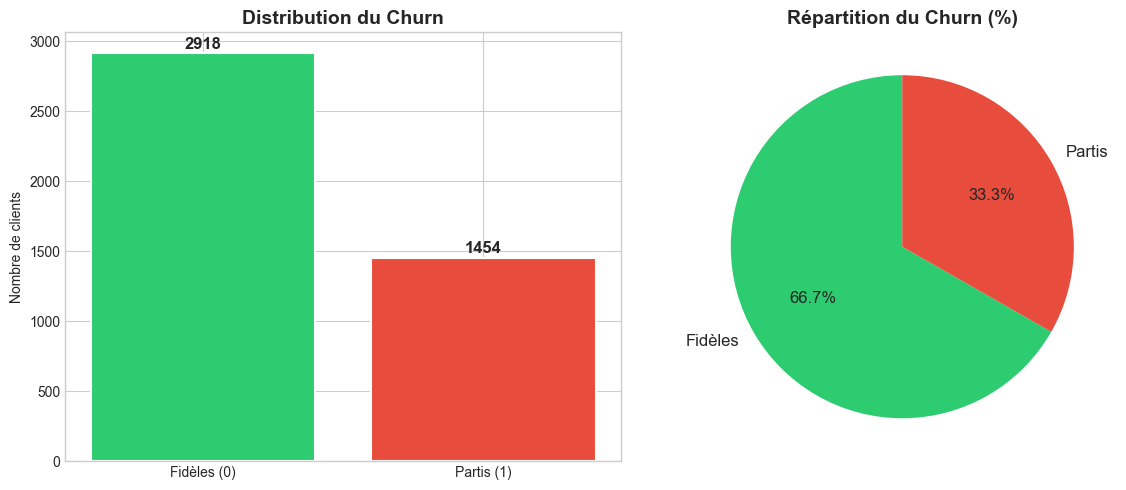

⚠️ Déséquilibre détecté : à traiter lors de la modélisation (SMOTE ou class_weight)


In [7]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('Distribution de la variable Churn :')
print(f'  Clients fidèles (0) : {churn_counts[0]} ({churn_pct[0]:.1f}%)')
print(f'  Clients partis  (1) : {churn_counts[1]} ({churn_pct[1]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
axes[0].bar(['Fidèles (0)', 'Partis (1)'], churn_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution du Churn', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(churn_counts.values, labels=['Fidèles', 'Partis'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Répartition du Churn (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('⚠️ Déséquilibre détecté : à traiter lors de la modélisation (SMOTE ou class_weight)')

Features avec des valeurs manquantes :
                         Valeurs manquantes  Pourcentage (%)
Age                                    1311            29.99
AvgDaysBetweenPurchases                  79             1.81


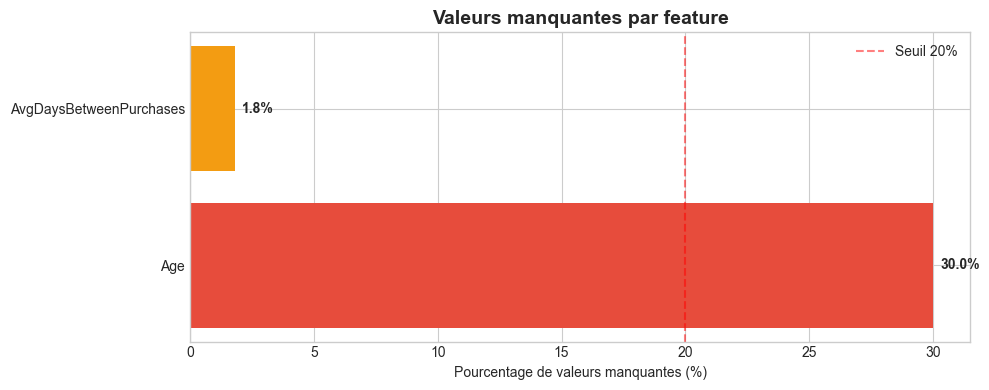

In [ ]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
#tableau récapitulatif des valeurs manquantes
missing_df = pd.DataFrame({ 
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct.round(2)
}).query('`Valeurs manquantes` > 0').sort_values('Pourcentage (%)', ascending=False)

print('Features avec des valeurs manquantes :')
print(missing_df)
# Visualisation des valeurs manquantes en cas d existence
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(missing_df.index, missing_df['Pourcentage (%)'],
                   color=['#e74c3c' if x > 20 else '#f39c12' for x in missing_df['Pourcentage (%)']])
    ax.set_xlabel('Pourcentage de valeurs manquantes (%)')
    ax.set_title('Valeurs manquantes par feature', fontsize=14, fontweight='bold')
    ax.axvline(x=20, color='red', linestyle='--', alpha=0.5, label='Seuil 20%')
    for bar, val in zip(bars, missing_df['Pourcentage (%)']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../reports/missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()

In [10]:
# SatisfactionScore : valeurs invalides (-1, 99)
print('SatisfactionScore: ')
print('Valeurs uniques :', sorted(df['SatisfactionScore'].dropna().unique()))
print('Valeurs invalides (-1) :', (df['SatisfactionScore'] == -1).sum())
print('Valeurs invalides (99) :', (df['SatisfactionScore'] == 99).sum())
print()

# SupportTicketsCount : valeur invalide (-1)
print('SupportTicketsCount: ')
print('Valeurs uniques :', sorted(df['SupportTicketsCount'].dropna().unique()))
print('Valeurs invalides (-1) :', (df['SupportTicketsCount'] == -1).sum())
print('Valeurs invalides (999) :', (df['SupportTicketsCount'] == 999).sum())
print()

# NewsletterSubscribed : variance nulle
print('NewsletterSubscribed: ')
print(df['NewsletterSubscribed'].value_counts())
print('⚠️ Variance nulle → sera supprimée')

SatisfactionScore: 
Valeurs uniques : [np.float64(-1.0), np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(99.0)]
Valeurs invalides (-1) : 115
Valeurs invalides (99) : 114

SupportTicketsCount: 
Valeurs uniques : [np.float64(-1.0), np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(999.0)]
Valeurs invalides (-1) : 43
Valeurs invalides (999) : 87

NewsletterSubscribed: 
NewsletterSubscribed
Yes    4372
Name: count, dtype: int64
⚠️ Variance nulle → sera supprimée


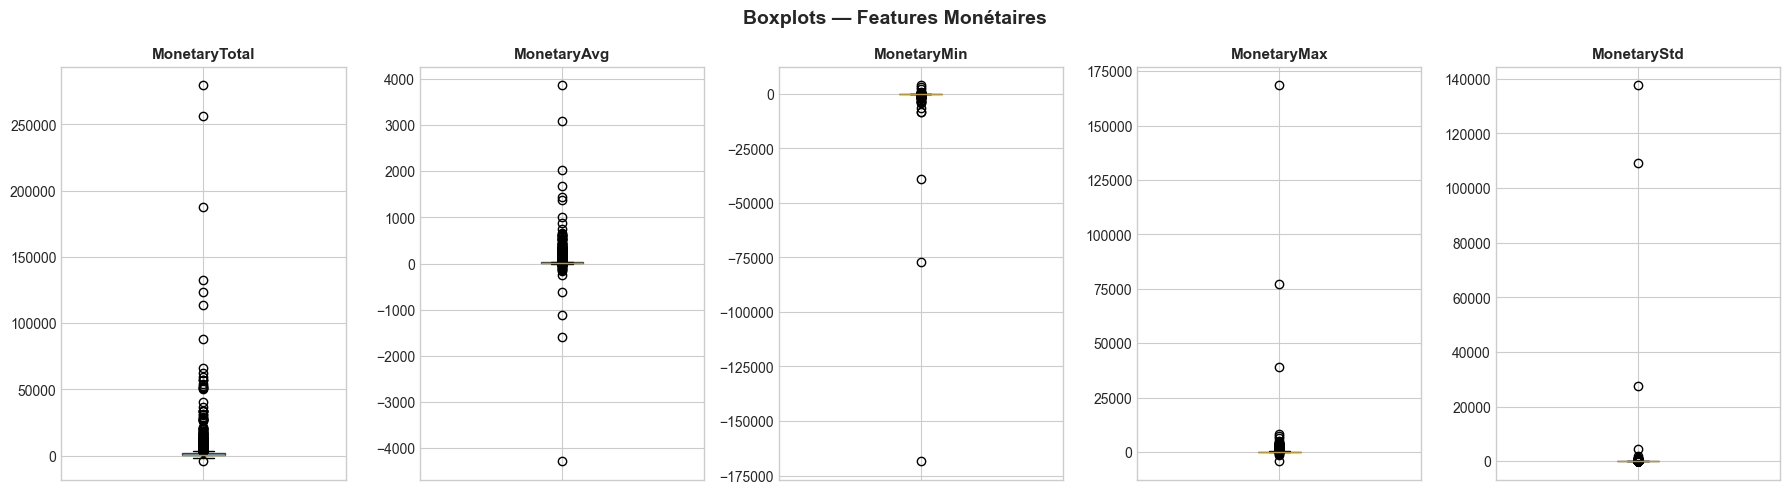

In [11]:
# Boxplots des features monétaires pour détecter les outliers
monetary_cols = ['MonetaryTotal', 'MonetaryAvg', 'MonetaryMin', 'MonetaryMax', 'MonetaryStd']

fig, axes = plt.subplots(1, len(monetary_cols), figsize=(18, 5))
for ax, col in zip(axes, monetary_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.7))
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xticklabels([])

plt.suptitle('Boxplots — Features Monétaires', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/boxplots_monetary.png', dpi=150, bbox_inches='tight')
plt.show()

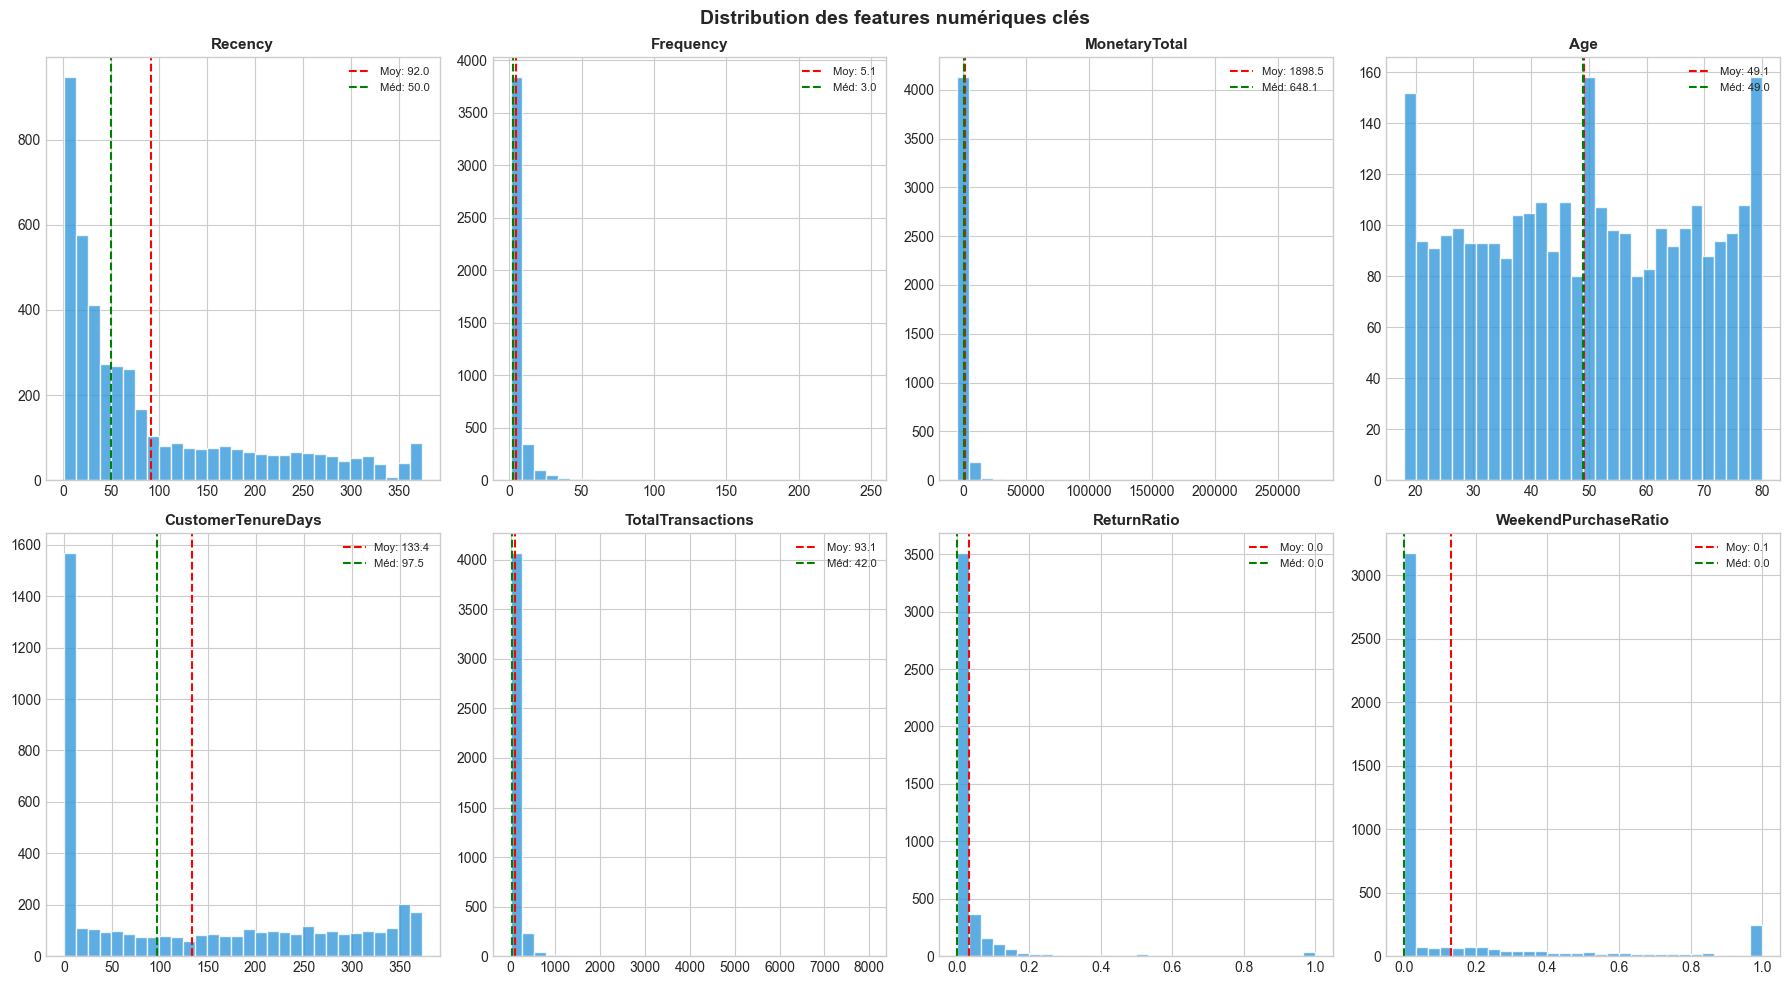

In [12]:
# Histogrammes des principales features numériques
key_num = ['Recency', 'Frequency', 'MonetaryTotal', 'Age',
           'CustomerTenureDays', 'TotalTransactions', 'ReturnRatio', 'WeekendPurchaseRatio']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, key_num):
    data = df[col].dropna()
    ax.hist(data, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Moy: {data.mean():.1f}')
    ax.axvline(data.median(), color='green', linestyle='--', linewidth=1.5, label=f'Méd: {data.median():.1f}')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Distribution des features numériques clés', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/distributions_numeriques.png', dpi=150, bbox_inches='tight')
plt.show()

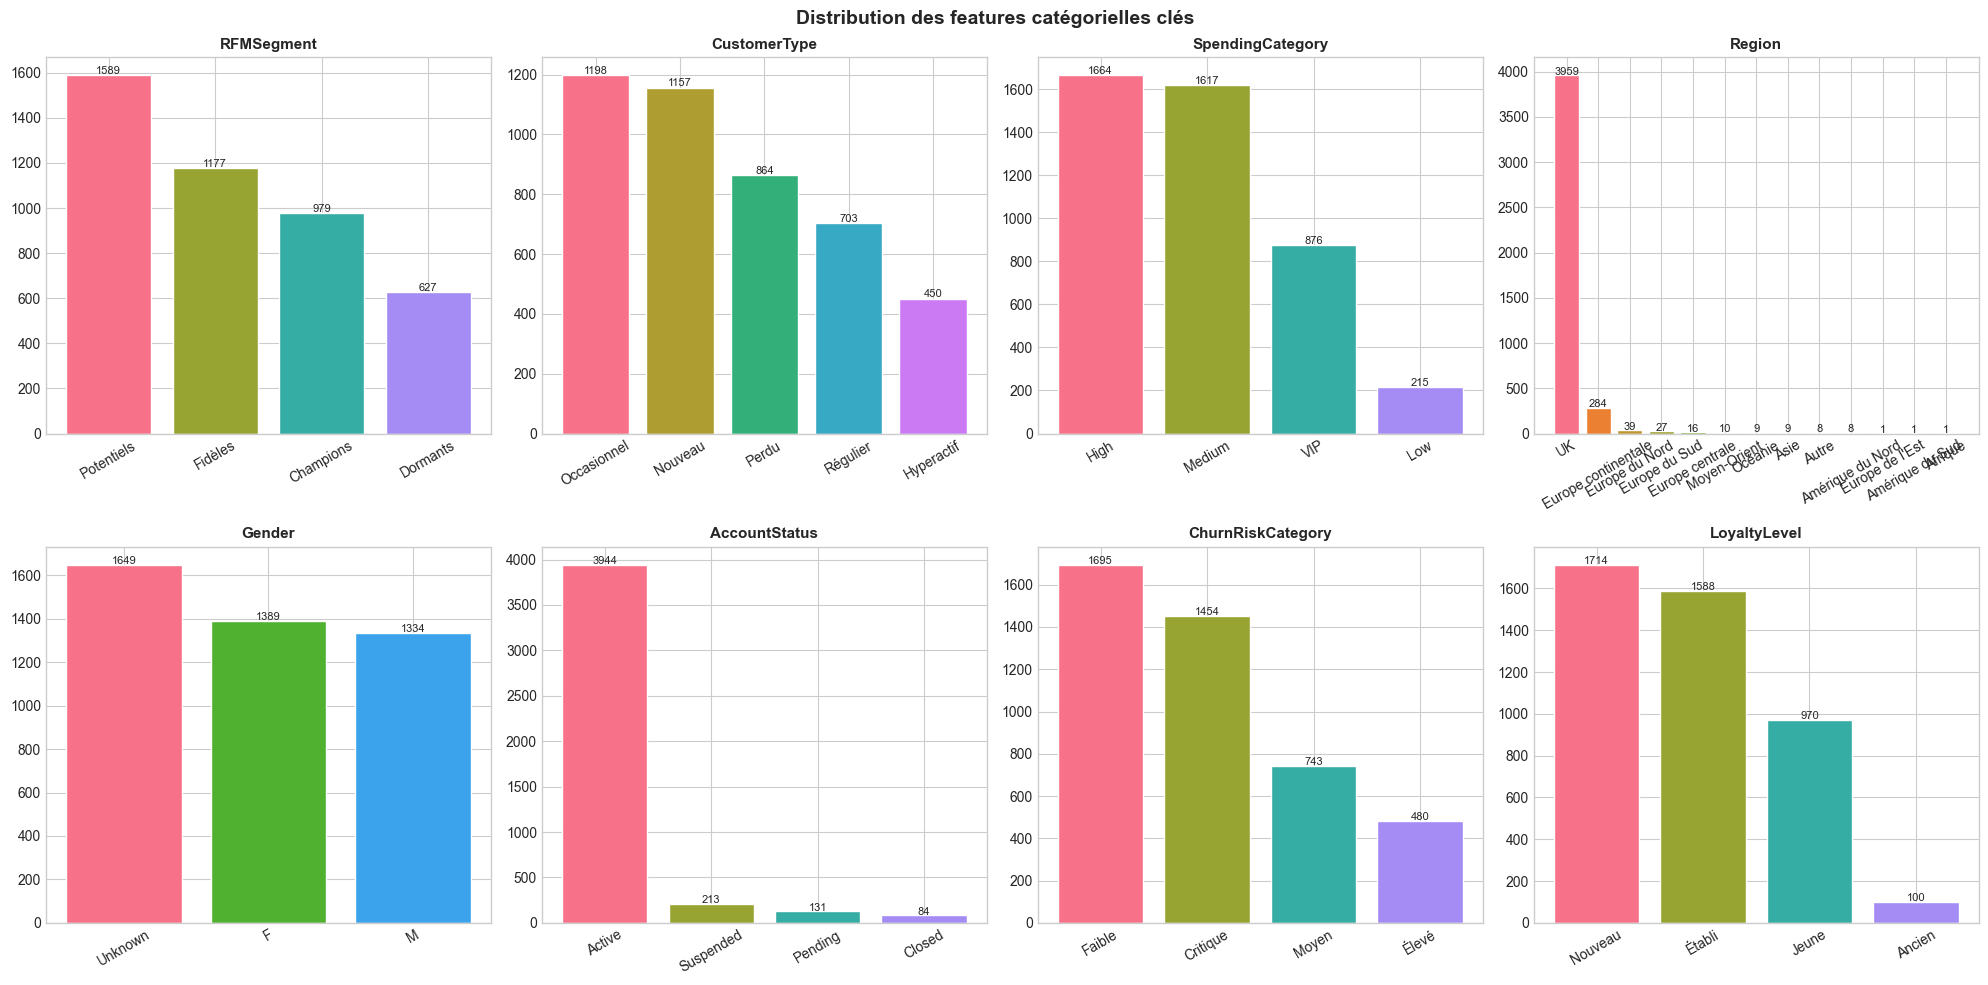

In [13]:
key_cat = ['RFMSegment', 'CustomerType', 'SpendingCategory',
           'Region', 'Gender', 'AccountStatus', 'ChurnRiskCategory', 'LoyaltyLevel']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, col in zip(axes, key_cat):
    counts = df[col].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=sns.color_palette('husl', len(counts)),
                  edgecolor='white')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', fontsize=8)

plt.suptitle('Distribution des features catégorielles clés', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/distributions_categorielles.png', dpi=150, bbox_inches='tight')
plt.show()

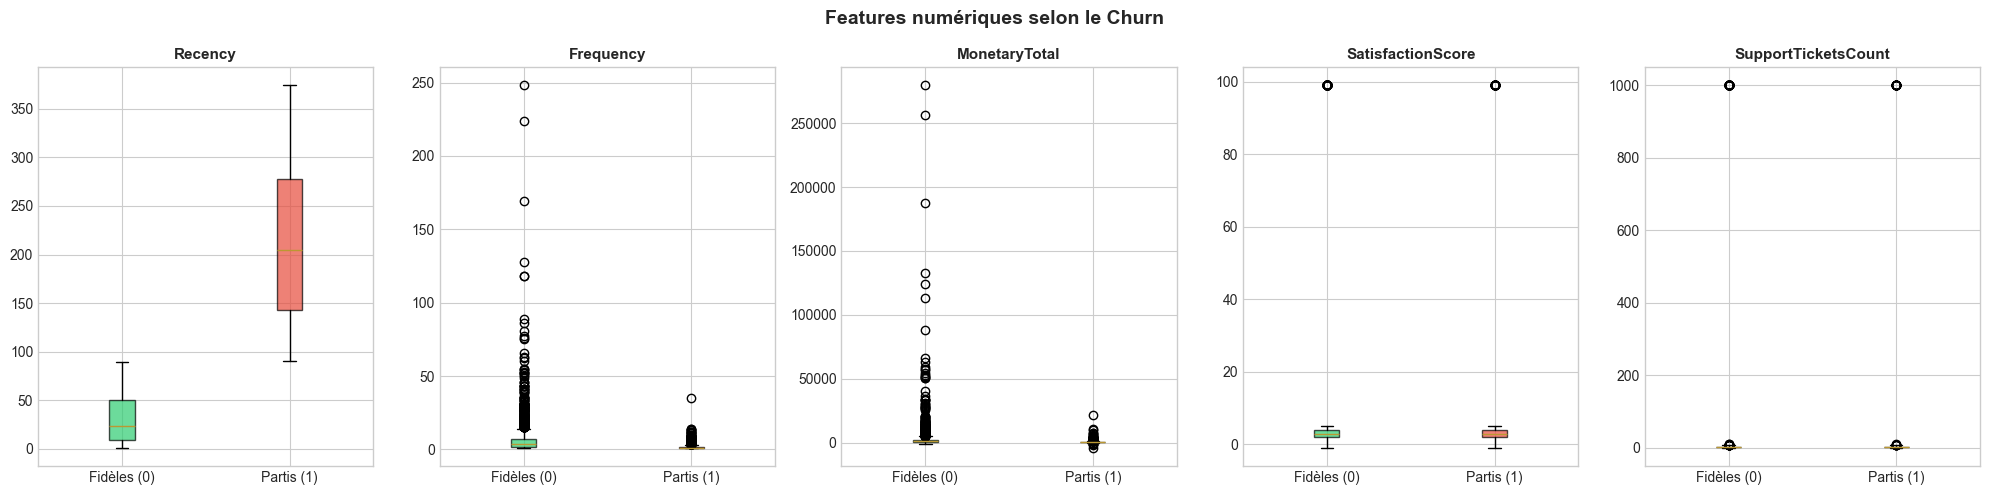

In [14]:
# Comparer les features numériques selon le Churn
churn_compare = ['Recency', 'Frequency', 'MonetaryTotal', 'SatisfactionScore', 'SupportTicketsCount']

fig, axes = plt.subplots(1, len(churn_compare), figsize=(20, 5))

for ax, col in zip(axes, churn_compare):
    data_0 = df[df['Churn'] == 0][col].dropna()
    data_1 = df[df['Churn'] == 1][col].dropna()
    ax.boxplot([data_0, data_1], patch_artist=True,
               boxprops=dict(alpha=0.7),
               labels=['Fidèles (0)', 'Partis (1)'])
    boxes = ax.patches
    if len(boxes) >= 2:
        boxes[0].set_facecolor('#2ecc71')
        boxes[1].set_facecolor('#e74c3c')
    ax.set_title(col, fontsize=11, fontweight='bold')

plt.suptitle('Features numériques selon le Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/features_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

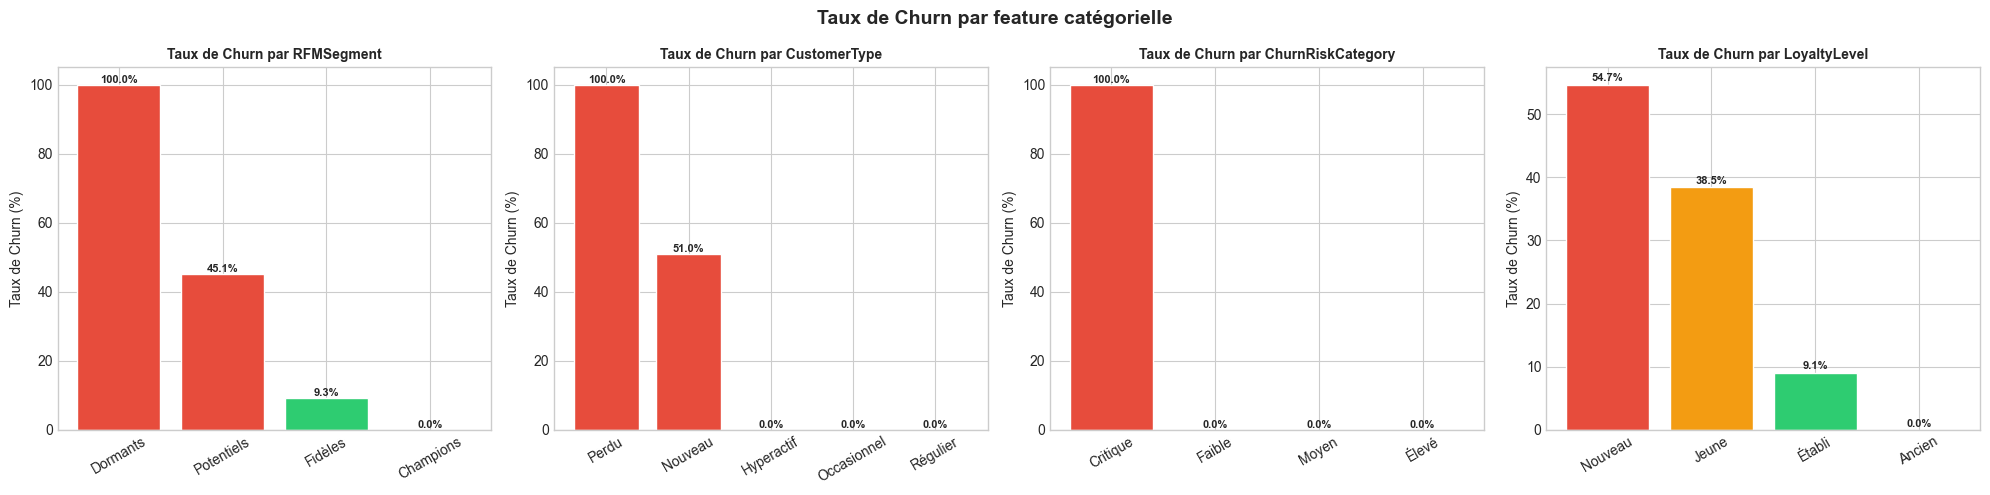

In [15]:
# Taux de churn par catégorie
cat_churn = ['RFMSegment', 'CustomerType', 'ChurnRiskCategory', 'LoyaltyLevel']

fig, axes = plt.subplots(1, len(cat_churn), figsize=(20, 5))

for ax, col in zip(axes, cat_churn):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    bars = ax.bar(churn_rate.index, churn_rate.values * 100,
                  color=['#e74c3c' if x > 0.4 else '#f39c12' if x > 0.25 else '#2ecc71'
                         for x in churn_rate.values],
                  edgecolor='white')
    ax.set_title(f'Taux de Churn par {col}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Taux de Churn (%)')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val*100:.1f}%', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Taux de Churn par feature catégorielle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/churn_rate_categories.png', dpi=150, bbox_inches='tight')
plt.show()

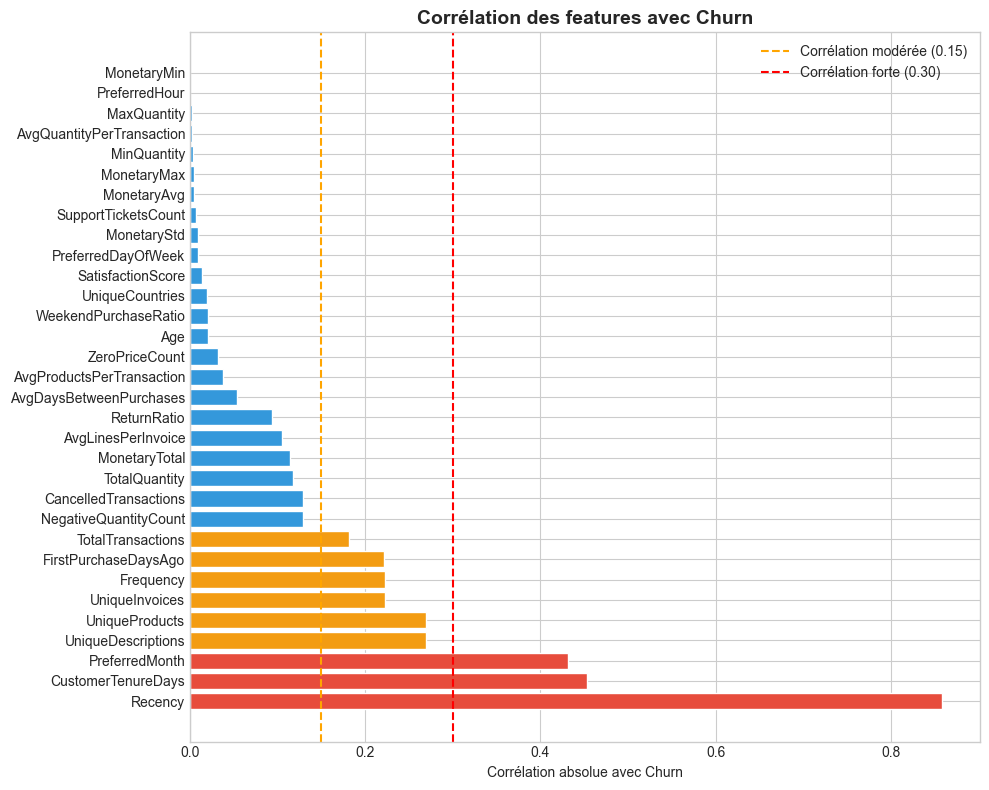

Top 10 features les plus corrélées avec Churn :
Recency                  0.858951
CustomerTenureDays       0.453455
PreferredMonth           0.430943
UniqueDescriptions       0.269835
UniqueProducts           0.269833
UniqueInvoices           0.222616
Frequency                0.222616
FirstPurchaseDaysAgo     0.221612
TotalTransactions        0.181653
NegativeQuantityCount    0.128954
Name: Churn, dtype: float64


In [18]:
# Features les plus corrélées avec Churn
corr_churn = df[corr_cols].corr()['Churn'].drop('Churn').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if v > 0.3 else '#f39c12' if v > 0.15 else '#3498db'
          for v in corr_churn.values]
plt.barh(corr_churn.index, corr_churn.values, color=colors, edgecolor='white')
plt.axvline(x=0.15, color='orange', linestyle='--', label='Corrélation modérée (0.15)')
plt.axvline(x=0.30, color='red', linestyle='--', label='Corrélation forte (0.30)')
plt.xlabel('Corrélation absolue avec Churn')
plt.title('Corrélation des features avec Churn', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/correlation_with_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features les plus corrélées avec Churn :')
print(corr_churn.head(10))

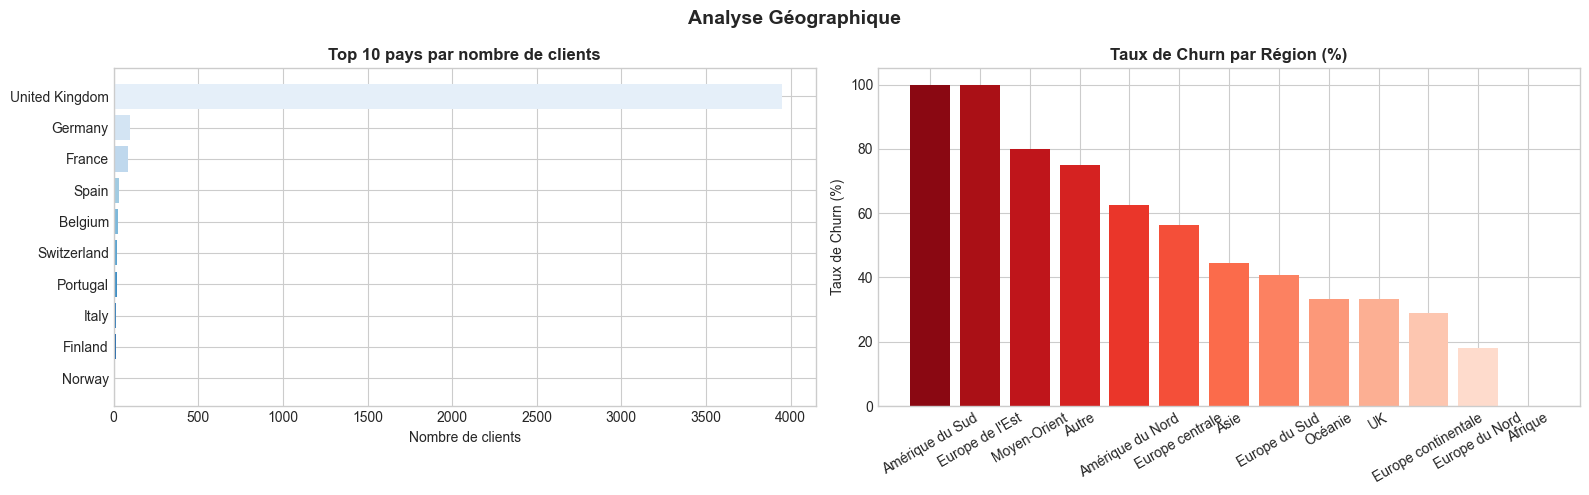

In [19]:
# Top 10 pays
top_countries = df['Country'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Répartition clients par pays
axes[0].barh(top_countries.index[::-1], top_countries.values[::-1],
             color=sns.color_palette('Blues_r', 10))
axes[0].set_title('Top 10 pays par nombre de clients', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nombre de clients')

# Taux de churn par région
churn_region = df.groupby('Region')['Churn'].mean().sort_values(ascending=False)
axes[1].bar(churn_region.index, churn_region.values * 100,
            color=sns.color_palette('Reds_r', len(churn_region)))
axes[1].set_title('Taux de Churn par Région (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Taux de Churn (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Analyse Géographique', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/analyse_geographique.png', dpi=150, bbox_inches='tight')
plt.show()